# Feature analysis — micro-price premium

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`microprice_premium` / `premium_gap` functions in §3. The data loading, the checks, and the
plots adapt on their own.

**The example** is the **micro-price premium**: each venue's best-bid/ask sizes tell you which way
the touch is *leaning* — a big bid and a thin ask means buyers crowd the book and the mid is about
to tick up. The Stoikov micro-price turns the two L1 sizes into a fair value between the quotes, and
the **premium** `(microprice − mid)/mid` is how far that fair value sits from the current mid. We
smooth it per venue (where the touch leans) and look at the cross-venue **premium gap** (one venue
leaning before byb does) as a lead. It is the single strongest L1 next-mid predictor, and we check
both heads.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature (the per-venue premium *is* poolable — a per-exchange number; the cross-venue
  *gap* legs are not), first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — the premium is a bounded ratio (`±halfspread/mid`), so §2 and §5 *measure* its
  invariance before deciding (the "raw-first" rule); we do not σ-divide it by reflex.
- **Don't invent your own vol/rate scale.** When you *do* normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the per-venue
  premium legs, the cross-venue gap, `σ_ev`, `λ_ev` — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a new book, a byb move — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For a premium leg that relevant event is a book update on
  *its own* venue; for `σ_ev` it is a byb mid-move. A value that ignores the book updates since the last clock
  read is **stale** — wrong, and a silent source of lag. The choice of EMA *and when it updates* is what makes
  the inter-trade read well-behaved — pick both deliberately (see the "Choosing the EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for a premium leg, a book update on *this* venue; for `σ_ev`, a byb mid-move. A timestamp with only
  **irrelevant** events injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, microprice premium); a **flow** **sums** the records at that timestamp
  (`σ_ev` sums squared moves). So a backed-up burst of N book updates at one
  instant is still **one** weight-1 sample — value = the final book's premium — **never** N
  samples. Injecting N silently overweights exactly the instants where a feed stalled and dumped a burst
  (N× weight on the `E/W` mean at one timestamp). The level-read face of the same trap: `σ_ev` counts squared
  mid-*moves*, so N simultaneous records fabricate N−1 phantom moves and inflate volatility (per-record, σ_ev
  read **0.13** off; one sample per timestamp made it **bit-exact**).
- **Do always read the *freshest* value — never freeze on the last trade's.** An EMA decays once
  per trade-timestamp (that fixes its memory in trade-count), but its *read* must use the latest data: fold
  in the current value as of now — the latest relevant timestamp (book update / mid-move) since the last
  trade — never the stale snapshot frozen at the last trade tick. Use a trade-weighted EMA with a **live
  front**: `read = (1 − α)·committed + α·current_value`, current between trades. Keep the two clocks
  separate, though: refresh the *read* at each relevant **timestamp**, but keep the *decay/weighting* on
  the trade clock — push a fresh *sample* once per book-update **timestamp** (one per timestamp, not per
  message); pushing per message would *message-rate-weight by quote activity*, which here cost ~0.01–0.02
  rank-IC by up-weighting churny stretches the trade clock usefully filters out. (Freshness itself measured ≈neutral for a 100 ms target — so reading fresh
  costs nothing and is the right default; never deliberately use stale information.)
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (here, byb's own
  mid-moves — `σ_ev` is itself such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W`, both decayed every
  trade-timestamp yet each pushed a sample only at the timestamps carrying its own events — read as the ratio `E / W`, which cancels the
  in-between decay and the warm-up bias. Dividing by `W` cancels the foreign-event decay exactly,
  so an `E / W` on the **combined** trade clock at span `N` approximates that exchange's **own**-clock
  EMA at a rescaled span — roughly `N` times that exchange's share of the combined trade rate — i.e. you get genuine per-exchange stats from the one shared clock. (That
  merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N` where the
  cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head will learn the
  magnitude itself, *and* learn that a +lean on one exchange can cancel a −lean on another
  (or reinforce it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (the premium is exactly such a bounded ratio), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | the Stoikov micro-price premium per venue — how far the size-weighted fair value sits from the mid — smoothed over time-scales, plus the cross-venue premium gap |
| **feeds** | both heads — *direction* (price head: which way byb moves) and *intensity* (rate head: how many moves); both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** The best bid and best ask each carry a size. When the bid size dwarfs the ask
size, buyers are crowding the book — the next mid-move is more likely *up* than down. The
**Stoikov micro-price** turns the two L1 sizes into a fair value between the quotes,

`microprice = (bid_qty · ask_prc + ask_qty · bid_prc) / (bid_qty + ask_qty)`

— note the *cross* weighting: a heavy bid pulls the fair value toward the **ask** (price about to
rise). The **premium** is how far that fair value sits from the current mid, as a fraction:

`prem = (microprice − mid) / mid`

A positive premium means the touch leans up; a negative one, down. We smooth `prem` per venue
over a family of time-scales (where the touch is leaning, slow vs fast), and separately look at
the cross-venue **premium gap** `prem(other) − prem(byb)` — one venue's touch leaning before
byb's has — as a lead.

**Why it should work.** The size imbalance at the touch is the most direct, lowest-latency read
of imminent pressure: it is *the* book state the next tick resolves. Stoikov's micro-price is the
fair-value estimator built exactly for "where will the mid be an instant from now," so its premium
over the mid is a mechanical forecast of byb's next move. The cross-venue **gap** is the second
hypothesis: that one venue's touch leaning before byb's adds information about byb's next move. The
*direction* of that information is **not pinned down a priori** — a "lead" story says a venue leaning up
precedes byb rising (a +gap → +byb relationship), but an equally plausible "byb-already-moved" story says
the gap opens *because byb already ticked* and the foreign venue hasn't caught up, which precedes byb
**reverting** (a −gap → +byb relationship). We don't assume which; §6 *measures* the sign, and the model
is fed the signed gap and learns it.

**What would disprove it.** *For the premium:* no predictive power at any time-scale, or power that
vanishes once we account for volatility (it was only tracking vol), or power that survives **only** as the
contemporaneous echo (a high backward IC with a forward IC that collapses to ≈0 once the move already
underway is netted out — the echo-netting section measures exactly this). *For the gap:* a measured sign with
either polarity is consistent with *a* mechanism, so the gap is disproved only by **no** power of either
sign once gated — not by coming out with a particular sign.

**Raw or normalised?** `prem` is a ratio bounded by `±halfspread/mid` (a heavy bid can pull the
fair value at most to the ask, i.e. half a spread above the mid), so it is *plausibly* already
regime-invariant with no division. But the spread itself widens in wild markets, so the bound is
not constant — we **build it raw and measure** Gate A in §5/§6 before deciding (the
"raw-first" rule). Never assume; the number decides.

> **No fixed leader.** It's tempting to call one exchange "the leader." Don't — leadership
> moves around, and any exchange can lead at any moment. So build the feature *the same way
> for every exchange and keep them all*. Here we keep each venue's own premium *and* both
> cross-venue gaps; §9 covers per-venue vs pooled.

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). Each premium leg is a **forward-filled level**
(it has a value at every instant) — the textbook case for the live-front read; `σ_ev`/`λ_ev` are sparse
flows. Choose the EMA type and injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (byb's mid-moves): use
  **`KernelMeanEMA`**, the self-normalising `E / W`. The `W` denominator counts only the events that
  carry the quantity, so the read is a *per-event mean*.
- A **forward-filled level** — defined at every instant (a price, the micro-price premium, a cross-venue
  premium gap): use **`LiveFrontEMA`**, which reads the committed mean carried one step toward the
  freshest value, `(1 − α)·committed + α·latest` — current between trades, never frozen on the last trade.
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (premium, gap, price) |
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (`σ_ev`: push `r²` only on a byb move) |

Classify the timestamp for the EMA being updated. For a premium leg, a book-update timestamp refreshes the
live front and a trade-timestamp commits + ticks the clock. For `σ_ev`, a trade-only timestamp decays the
clock and injects no sample; a byb mid-move injects its `r²`.

Between trades:

- **React at every relevant timestamp, and read the freshest value.** Decay rides the trade clock, but the
  EMA must *update* at every timestamp that can move it (same-timestamp events as one update), and the read must reflect the timestamps since the last
  trade — never a stale snapshot.
- **Records sharing a timestamp are ONE update, not a sequence** — apply them all, then register a single
  update (one premium per venue, one move, one refresh).

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A stray
forward-fill is the usual way to break this by accident.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in clock-seconds; that keeps the feature's meaning
steady whether trading is fast or slow. Book-update timestamps between trades refresh what the EMA *reads*, but
they do **not** advance the clock — only a trade does, decaying each EMA once.

**Comparable across calm and wild markets** — and here is the twist for *this* feature. A raw price
*level* is bigger in volatile markets and needs `σ_ev` divided out. But the micro-price **premium** is
already a **bounded ratio** — `prem = (microprice − mid)/mid` lies within `±halfspread/mid` because the
size-weighted fair value can never leave the bid-ask. So it is *a priori* close to regime-invariant with
**no division**. We obey the **raw-first rule**: build it raw, then in §5/§6 *measure* Gate A's scale across
volatility buckets. If that scale is small (< ~3×) we ship it raw; only if it fails do we try `/σ_ev`
(divide vol out) or `/λ_ev` (divide rate out) and keep whichever is invariant. Never assume — measure.

**2a — The atom** (per venue, one line):

`microprice = (bid_qty · ask_prc + ask_qty · bid_prc) / (bid_qty + ask_qty)`
`prem       = (microprice − mid) / mid`,   `mid = (bid_prc + ask_prc) / 2`

Both the micro-price and the mid come from the **same L1 snapshot** of that venue's book, so the
premium is a pure within-book *lean* — sign = which way the touch is tilted, magnitude ≤ half a spread.
It needs the best-bid/ask **sizes**, which live in `front_levels` (the raw BBO stream) — `merged_levels`
is deliberately price-only (no sizes), so **every venue's premium is built from `front_levels`**, byb
included. (The byb mid used for the *target* and the *yardsticks* still uses the trade-fused merged byb
mid, as in the template — only the premium atom uses the raw book, because that is where the sizes are.)

**2b — The two features built on the atom:**

1. **Per-venue smoothed premium** `ema(prem_ex, N)` — where venue `ex`'s touch is leaning, smoothed over
   the trade clock at span `N`. One per venue (byb, okx, bin); each predicts byb. A bigger `N` is a
   steadier read of the lean; `N = 1` is the instantaneous premium.
2. **Cross-venue premium gap** `ema(prem_other − prem_byb, N)` — how much *more* another venue's touch
   is leaning than byb's. This carries cross-venue information about byb's next move, but its **sign is
   measured, not assumed** (§6): it could be a *lead* (foreign lean precedes byb moving the same way, +gap
   → +byb) or *mean-reversion/echo* (the gap opened because byb already ticked, so it precedes byb
   reverting, −gap → +byb). One per other venue (okx−byb, bin−byb); the model is fed the signed gap.

**2c — The EMA we use, and how it updates** (applying the two choices from the section above):

- Each leg (a per-venue premium, or a cross-venue gap) is a **forward-filled level** — it has a value at
  every instant — so it is a **`LiveFrontEMA`** read as a **live front**: `(1 − α)·(value committed at the
  last trade) + α·(the premium/gap right now)`. We **commit** once per trade-timestamp (trade-dwell
  weighting, the right average for a level) and **refresh** the live front at each book-update timestamp, so the
  read is current between trades, never frozen. `N = 1` sets `α = 1`, collapsing the leg to the fresh
  premium itself (no smoothing).
- **`σ_ev` and `λ_ev`** (the yardsticks) are a **sparse flow** — byb moves on only *some* events — so
  each is a **`KernelMeanEMA`** read as `E / W` (this feature *uses* them only as the target denominator,
  controls / optional normalisers, not in the atom; built exactly as in the template).

§3 builds exactly this; §4 re-derives it from raw events and confirms it to floating-point precision.

The cell below loads the data, builds the shared trade clock, computes **both yardsticks** as `E/W`
flows on that clock (span `YARDSTICK_N`), and computes each venue's micro-price premium from its raw
`front_levels` book.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block
import boba.io as io

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict
VENUES      = ["byb", "okx", "bin"]              # all three venues carry a micro-price premium; byb is also the target
OTHERS      = ["okx", "bin"]                     # the venues whose premium GAP vs byb is a cross-venue lead
NSPANS      = [1, 5, 20, 50, 200, 1000, 5000]   # EMA spans to sweep (single-EMA family; N=1 = instantaneous premium, no smoothing)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, target + controls only
# freshest byb merged mid (trade-fused) for the TARGET and YARDSTICKS; the PREMIUM atom uses each venue's RAW front_levels book (it needs the L1 SIZES, which merged_levels deliberately drops).
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# --- each venue's micro-price premium, from its RAW front_levels book (bid/ask price AND size) ---
def load_prem(ex):
    df = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls()
          .filter((pl.col("bid_qty") > 0) & (pl.col("ask_qty") > 0)))     # need both sizes for the weighting
    rx = df["rx_time"].cast(pl.Int64).to_numpy()
    bp, bq = df["bid_prc"].to_numpy(), df["bid_qty"].to_numpy()
    ap, aq = df["ask_prc"].to_numpy(), df["ask_qty"].to_numpy()
    mid   = 0.5 * (bp + ap)
    micro = (bq * ap + aq * bp) / (bq + aq)                               # Stoikov micro-price: heavy bid -> pulled toward the ASK
    return rx, (micro - mid) / mid                                        # prem = (microprice − mid)/mid, bounded by ±halfspread/mid
prems = {ex: load_prem(ex) for ex in VENUES}                             # rx-sorted premium stream per venue

# byb merged mid (trade-fused) for the target + yardsticks (same logic as the template; the premium does NOT use it)
byb_fl = (load_block(block, TARGET, "merged_levels").select("rx_time", "bid_prc", "ask_prc").drop_nulls())
byb_mid_rx = byb_fl["rx_time"].cast(pl.Int64).to_numpy()
byb_mid_v  = (byb_fl["bid_prc"].to_numpy() + byb_fl["ask_prc"].to_numpy()) / 2

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in VENUES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

def prem_on_clock(ex):                             # causal: each venue's most-recent premium at-or-before every clock tick
    rx, p = prems[ex]
    return p[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(p) - 1)]

# Both yardsticks react to EVERY byb merged-mid change — defined at every instant, never the net move per trade.
# They decay once per TRADE (memory in trade count) but INJECT on every byb mid-move. σ_ev = √(E/W) over byb MOVES
# (E = squared returns, W = move count); λ_ev = W / E_dt is byb mid-moves per second.
keep = np.concatenate([byb_mid_rx[1:] != byb_mid_rx[:-1], [True]])               # collapse same-TIMESTAMP rows to ONE update (the final mid)
byb_rx, byb_mid = byb_mid_rx[keep], byb_mid_v[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
for ex in VENUES:
    rx, p = prems[ex]
    print(f"{ex} premium: {len(p):,} book updates  median|prem| {np.median(np.abs(p)):.2e}  bounded ratio")
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (target + controls only)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
byb premium: 1,378,423 book updates  median|prem| 1.52e-06  bounded ratio
okx premium: 2,043,358 book updates  median|prem| 1.25e-06  bounded ratio
bin premium: 24,773,747 book updates  median|prem| 2.24e-06  bounded ratio
yardsticks: react to every byb mid-move; decay span 10000 trades (target + controls only)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per ingested event (no growing buffers). They have to agree,
which §4 checks.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute every leg of the feature at each grid point.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(NSPANS))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both yardsticks at each grid point (the same span-YARDSTICK_N trade-tick EMA)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

# the committed premium per venue on the trade clock, and the fresh premium AT each grid anchor (every book update, never stale)
prem_committed = {ex: prem_on_clock(ex) for ex in VENUES}          # each venue's premium forward-filled onto the trade clock (committed legs)
def _prem_at(ex, t):                                               # a venue's premium forward-filled to arbitrary times (the FRESH read)
    rx, p = prems[ex]; return p[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(p) - 1)]
prem_anchor = {ex: _prem_at(ex, anchor_ts) for ex in VENUES}       # the premium as of each grid anchor — fresh, never frozen at the last trade

def ema(x, N):
    if N == 1: return x                                            # all weight on the latest tick
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def live_front(committed, fresh, N):           # LiveFrontEMA read: (1-α)·committed-at-last-trade + α·fresh, read at the grid
    a = 2.0 / (N + 1.0)
    return (1.0 - a) * ema(committed, N)[tick_at_anchor] + a * fresh

# the two feature families, RAW (no σ_ev division — prem is a bounded ratio; §5/§6 measure whether it needs normalising):
def microprice_premium(ex, N):                 # (1) per-venue smoothed premium — where venue ex's touch is leaning
    return live_front(prem_committed[ex], prem_anchor[ex], N)
def premium_gap(ex, N):                         # (2) cross-venue gap: how much MORE `ex` leans than byb (a lead)
    gap_committed = prem_committed[ex] - prem_committed["byb"]
    gap_fresh     = prem_anchor[ex]    - prem_anchor["byb"]
    return live_front(gap_committed, gap_fresh, N)
print(f"grid: {len(anchor_ts):,} anchors   |   legs: {len(VENUES)} per-venue premiums + {len(OTHERS)} cross-venue gaps, swept over {len(NSPANS)} spans")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors   |   legs: 3 per-venue premiums + 2 cross-venue gaps, swept over 7 spans


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two agree on real
data — a **parity check**, not an independent oracle. The streaming build is the **production** reference:
an O(1) state machine you push **raw events** into — `on_book(...)` for a top-of-book update carrying
prices *and* sizes, `on_trade()` for a trade — and read the current feature per leg from `value()`. State is
a few scalar EMAs per leg plus σ_ev's two EWMAs — no buffers, no history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each tagged by its full listing (e.g. `byb_eth_usdt_p`) and keyed by it. It
  builds each venue's **micro-price premium itself** from the latest `(bid_prc, bid_qty, ask_prc, ask_qty)`
  snapshot — exactly the §3 atom. (Unlike the template's gap, the premium uses the raw book for *every*
  venue, byb included, because it needs the L1 sizes; merged_levels has none.)
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh()`
  once** — which refreshes each leg's live front and injects σ_ev on a byb mid-move, then advances the
  clock **at most once** (decay σ_ev, commit each leg) and only if a trade landed.
- `value()` returns the live-front EMA of each leg — per-venue premium and cross-venue gap — current at
  the instant it's read.

We feed the **whole raw stream** — every venue's book updates and trades — into **one** builder and read
**all legs** at each grid anchor. If the online build reproduces §3's vectorized feature on real data,
the two implementations agree.

A second, independent definition oracle follows (§4b) — a dead-simple plain-numpy reimplementation with
**no shared code** that recomputes the atom from scratch, forward-fills it with an explicit loop, and
asserts the `±halfspread/mid` bound — the check CLAUDE.md's hard requirement asks for.

In [3]:
import math
from boba.ema import LiveFrontEMA, KernelMeanEMA   # live-front level read (premium/gap legs) + E/W flow mean (σ_ev), src/boba/ema.py

class LiveMicroprice:
    # Pure feature state machine. Each venue's micro-price premium is built INSIDE from the latest L1 snapshot
    # (bid/ask price AND size). Each leg (per-venue premium, cross-venue gap) is a LiveFrontEMA: on_book updates that
    # venue's stored book; refresh() (once per timestamp) pushes the fresh premium / gap into each leg's live front and,
    # if a trade landed, advances the clock once (decay σ_ev, commit each leg). value() reads the live front per leg.
    # σ_ev (a KernelMeanEMA E/W flow over byb MOVES) is built from the byb MERGED mid, exactly as in §2 — so it is fed a
    # SEPARATE byb mid stream (on_byb_mid), distinct from byb's front_levels book that drives byb's premium.
    # State is O(1), all scalar — no buffers, no history. WHEN to read (record value) is the caller's job.
    def __init__(self, target, venues, others, span, vol_span, short):
        self.target, self.venues, self.others = target, list(venues), list(others)
        self.short = dict(short)                                                  # full listing -> short venue code (for the output keys)
        self.bid_p = {}; self.bid_q = {}; self.ask_p = {}; self.ask_q = {}       # latest L1 snapshot per venue listing
        self.vol = KernelMeanEMA(vol_span)                                       # σ_ev: E/W mean of byb's squared moves -> sqrt(E/W)
        self.leg = {v: LiveFrontEMA(span) for v in self.venues}                  # per-venue premium leg (live-front)
        self.leg_gap = {o: LiveFrontEMA(span) for o in self.others}              # cross-venue gap leg (other − byb)
        self.prev = None                                                         # byb's last merged log-mid, to detect a real move
        self.was_trade_present = False                                           # did a trade land this timestamp? -> exactly one decay per timestamp

    def _prem(self, listing):                                                    # the micro-price premium of one venue's stored book
        bp, bq = self.bid_p.get(listing), self.bid_q.get(listing)
        ap, aq = self.ask_p.get(listing), self.ask_q.get(listing)
        if bp is None or ap is None or bq is None or aq is None or bq <= 0 or aq <= 0:
            return None
        mid = 0.5 * (bp + ap)
        micro = (bq * ap + aq * bp) / (bq + aq)
        return (micro - mid) / mid

    def on_book(self, listing, bid_p, bid_q, ask_p, ask_q):                      # BBO update -> overwrite that venue's L1 snapshot (latest wins)
        self.bid_p[listing] = bid_p; self.bid_q[listing] = bid_q
        self.ask_p[listing] = ask_p; self.ask_q[listing] = ask_q

    def on_byb_mid(self, log_mid):                                               # a byb MERGED-mid update (drives σ_ev only; separate from byb's book)
        self._byb_log_mid = log_mid

    def on_trade(self):                                                          # any trade this timestamp -> the clock advances once (in refresh)
        self.was_trade_present = True

    def refresh(self):                                                           # ONE per TIMESTAMP: update the EMAs, then advance the clock AT MOST ONCE
        traded, self.was_trade_present = self.was_trade_present, False           # consume the flag — simultaneous prints = one decay, not many
        lt = getattr(self, "_byb_log_mid", None)
        if lt is not None:
            if self.prev is not None and lt != self.prev:
                self.vol.add((lt - self.prev) ** 2)                              # σ_ev reacts to EVERY byb mid-move — a real move injects its return²
            self.prev = lt
        pb = self._prem(self.target)                                            # byb's own premium (for the gap legs)
        for v in self.venues:                                                   # refresh each per-venue premium leg's live front
            p = self._prem(v)
            if p is not None: self.leg[v].add(p)
        for o in self.others:                                                   # refresh each cross-venue gap leg (other − byb)
            po = self._prem(o)
            if po is not None and pb is not None: self.leg_gap[o].add(po - pb)
        if traded: self.tick()                                                  # a trade landed -> advance the clock exactly once

    def tick(self):                                                             # advance the trade clock ONE step: decay σ_ev, commit each leg
        self.vol.tick()
        for v in self.venues: self.leg[v].tick()
        for o in self.others: self.leg_gap[o].tick()

    def value(self):                                                            # live-front read per leg, keyed by SHORT venue code (premium per venue + gap per other)
        out = {f"prem_{self.short[v]}": self.leg[v].value() for v in self.venues}
        out.update({f"gap_{self.short[o]}": self.leg_gap[o].value() for o in self.others})
        return out

# --- gather the WHOLE raw stream (every venue's front_levels book + trades + byb merged mid) over a slice ---
SPAN, N_GRID = 50, 40_000                          # validate ALL legs over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in VENUES]       # byb, okx, bin
cols = {k: [] for k in "rx kind lid bp bq ap aq".split()}   # kind 0=book, 1=trade, 2=byb-merged-mid
def add(rx, kind, lid, bp, bq, ap, aq):            # stage one source's events (kept ≤ cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    for k, v in (("bp", bp), ("bq", bq), ("ap", ap), ("aq", aq)):
        cols[k].append((v[m] if isinstance(v, np.ndarray) else np.full(n, v)).astype(float))
for lid, ex in enumerate(VENUES):                  # every venue's RAW front_levels book (price AND size)
    fl = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls()
          .filter((pl.col("bid_qty") > 0) & (pl.col("ask_qty") > 0)))
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid,
        fl["bid_prc"].to_numpy(), fl["bid_qty"].to_numpy(), fl["ask_prc"].to_numpy(), fl["ask_qty"].to_numpy())
add(byb_rx, 2, 0, np.log(byb_mid), 0.0, 0.0, 0.0)  # byb merged-mid stream (drives σ_ev); bp carries log-mid
for lid, ex in enumerate(VENUES):                  # trades from EVERY venue tick the shared clock
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))
    rx = td["rx_time"].cast(pl.Int64).to_numpy()
    add(rx, 1, lid, 0.0, 0.0, 0.0, 0.0)
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book(0) before trade(1) before mid(2) on ties
rxL, kindL, lidL, bpL, bqL, apL, aqL = (C[k][order].tolist() for k in "rx kind lid bp bq ap aq".split())
print(f"streaming {len(rxL):,} raw events (book + trades + byb mid, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once per timestamp, READ value() at every grid anchor ---
short_of = {f"{ex}_{COIN}": ex for ex in VENUES}                                          # full listing -> short venue code
feat = LiveMicroprice(TARGET, LISTINGS, [LISTINGS[1], LISTINGS[2]], SPAN, YARDSTICK_N, short_of)   # venues byb,okx,bin; others okx,bin
na = min(N_GRID, len(anchor_ts))
leg_names = [f"prem_{v}" for v in VENUES] + [f"gap_{o}" for o in OTHERS]
streams = {name: np.full(na, np.nan) for name in leg_names}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        v = feat.value()
        for name in leg_names: streams[name][ai] = v[name]
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if   kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], bpL[i], bqL[i], apL[i], aqL[i])
        elif kindL[i] == 1: feat.on_trade()
        else:               feat.on_byb_mid(bpL[i])
        i += 1
    feat.refresh()                                 # apply the timestamp: update EMAs, then advance the clock ONCE if any trade landed
while ai < na:                                     # trailing anchors after the last event
    v = feat.value()
    for name in leg_names: streams[name][ai] = v[name]
    ai += 1

# --- one stream -> all legs: check EACH against its §3 vectorized feature ---
print(f"one raw-event stream -> {len(leg_names)} live-front legs, vs the vectorized build (N={SPAN}):")
worst = 0.0
for v in VENUES:
    ref = microprice_premium(v, SPAN)[:na]; name = f"prem_{v}"
    both = np.isfinite(streams[name]) & np.isfinite(ref)
    diff = np.abs(streams[name][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  prem_{v}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-6, f"live build does not reproduce prem_{v}"
for o in OTHERS:
    ref = premium_gap(o, SPAN)[:na]; name = f"gap_{o}"
    both = np.isfinite(streams[name]) & np.isfinite(ref)
    diff = np.abs(streams[name][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  gap_{o}:   max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-6, f"live build does not reproduce gap_{o}"
print(f"parity: one raw-event stream reproduces ALL legs  (worst max|diff| {worst:.2e})  OK")

streaming 3,356,247 raw events (book + trades + byb mid, all venues) over ~40,000 grid points...


one raw-event stream -> 5 live-front legs, vs the vectorized build (N=50):
  prem_byb:  max |diff| 3.39e-21  on 40,000 grid points
  prem_okx:  max |diff| 3.39e-21  on 40,000 grid points
  prem_bin:  max |diff| 3.39e-21  on 40,000 grid points
  gap_okx:   max |diff| 8.47e-21  on 40,000 grid points
  gap_bin:   max |diff| 1.69e-21  on 40,000 grid points
parity: one raw-event stream reproduces ALL legs  (worst max|diff| 8.47e-21)  OK


**Conclusion (A — production shape).** From one stream of ~3.4 M raw events the streaming builder reproduces
**every** vectorized leg — the three per-venue premiums and both cross-venue gaps — to floating-point
precision (worst max |diff| ≈ **8e-21** over 40,000 grid points per leg, pure round-off from the EMAs'
recursive last-digit drift). The production shape (one feed in, a feature *per leg* out) computes exactly
what the offline analysis did, on the one shared trade clock. **But** because both paths build the atom and
the EMA the same way, this only proves the *plumbing* matches — it can't catch a wrong atom definition. That
is what the independent oracle below is for.

### 4b. Independent definition oracle — the atom from scratch, plus the `±halfspread/mid` bound

The §4 streaming check shares the `boba.ema` primitives with §3, so it validates the EMA bookkeeping, not
the **definition**. Here is the missing half: a **dead-simple, plain-numpy** reimplementation that
*never* touches a production helper. For one venue it (1) recomputes `prem` per book row directly from the
five raw columns, (2) **forward-fills** that premium to every grid anchor with an **explicit Python loop**
(a two-pointer walk — no `searchsorted`, no lfilter, no EMA class), and (3) reads the **shipped N=1 span**,
where the live-front read is the identity, so `microprice_premium(ex, 1)` *is* the forward-filled fresh
premium and the two must agree exactly. It also runs on a **later grid slice** (not the 0-prefix) so the
oracle isn't only exercising the warm-up. Finally it **asserts the bound** `|prem| ≤ 0.5·(ask−bid)/mid`
elementwise on every book row — the structural guarantee the verdict relies on, checked here, not asserted
in prose. (At N>1 a from-scratch loop oracle for the trade-clock live-front EMA is exactly the streaming
machine in §4(A); the *independent* thing to check is the atom + the identity-span read, which is what
ships.)

In [4]:
# --- (B) INDEPENDENT oracle: plain numpy, NO boba.ema, NO §3 helpers. Recompute the atom + forward-fill in a loop. ---
def prem_from_scratch(ex):                              # the micro-price premium per book row, from the five raw columns
    df = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls()
          .filter((pl.col("bid_qty") > 0) & (pl.col("ask_qty") > 0)))
    bp = df["bid_prc"].to_numpy(); bq = df["bid_qty"].to_numpy()
    ap = df["ask_prc"].to_numpy(); aq = df["ask_qty"].to_numpy()
    rxr = df["rx_time"].cast(pl.Int64).to_numpy()
    mid   = 0.5 * (bp + ap)
    micro = (bq * ap + aq * bp) / (bq + aq)             # Stoikov micro-price, written out plainly
    prem  = (micro - mid) / mid
    half  = 0.5 * (ap - bp) / mid                       # half-spread as a fraction of mid = the bound |prem| <= half
    return rxr, prem, half

def ffill_loop(rxr, prem, anchors):                     # explicit two-pointer forward-fill: last prem with rxr <= anchor
    out = np.full(len(anchors), np.nan); j = -1; m = len(rxr)
    for i, t in enumerate(anchors):                     # anchors are sorted, so the read pointer only moves forward
        while j + 1 < m and rxr[j + 1] <= t: j += 1
        if j >= 0: out[i] = prem[j]
    return out

# Bound check (elementwise, every book row) + N=1 identity-read match, on a LATER grid slice (not the warm-up prefix).
ORA_LO, ORA_HI = len(anchor_ts) // 2, len(anchor_ts) // 2 + 40_000     # a mid-block window, distinct from §4(A)'s 0-prefix
sl = anchor_ts[ORA_LO:ORA_HI]
print(f"independent oracle on a LATER slice: anchors [{ORA_LO:,}, {ORA_HI:,}) of {len(anchor_ts):,}")
ok2 = True
for ex in VENUES:
    rxr, prem_raw, half = prem_from_scratch(ex)
    assert np.all(np.abs(prem_raw) <= half + 1e-18), f"{ex}: |prem| exceeds halfspread/mid bound"   # the structural bound
    oracle_n1 = ffill_loop(rxr, prem_raw, sl)                                 # naive forward-fill = the N=1 premium
    prod_n1   = microprice_premium(ex, 1)[ORA_LO:ORA_HI]                      # §3 at the SHIPPED span (identity live-front)
    both = np.isfinite(oracle_n1) & np.isfinite(prod_n1)
    mx = float(np.nanmax(np.abs(oracle_n1[both] - prod_n1[both])))
    print(f"  prem_{ex}:  N=1 max |diff| {mx:.2e}  |  bound |prem|<=half OK on {len(prem_raw):,} rows")
    ok2 &= mx < 1e-12
# the cross-venue gap at N=1 is just the difference of two from-scratch premiums forward-filled independently
for o in OTHERS:
    rxo, premo, _ = prem_from_scratch(o); rxb, premb, _ = prem_from_scratch("byb")
    gap_oracle = ffill_loop(rxo, premo, sl) - ffill_loop(rxb, premb, sl)
    gap_prod   = premium_gap(o, 1)[ORA_LO:ORA_HI]
    both = np.isfinite(gap_oracle) & np.isfinite(gap_prod)
    mx = float(np.nanmax(np.abs(gap_oracle[both] - gap_prod[both])))
    print(f"  gap_{o}:   N=1 max |diff| {mx:.2e}")
    ok2 &= mx < 1e-12
assert ok2, "independent oracle disagrees with the §3 build at the shipped N=1 span"
print("independent oracle: from-scratch atom + explicit forward-fill reproduces the SHIPPED N=1 legs, and the ±halfspread/mid bound holds elementwise  OK")

independent oracle on a LATER slice: anchors [853,184, 893,184) of 1,706,369
  prem_byb:  N=1 max |diff| 0.00e+00  |  bound |prem|<=half OK on 1,378,423 rows


  prem_okx:  N=1 max |diff| 0.00e+00  |  bound |prem|<=half OK on 2,043,358 rows


  prem_bin:  N=1 max |diff| 0.00e+00  |  bound |prem|<=half OK on 24,773,747 rows


  gap_okx:   N=1 max |diff| 0.00e+00


  gap_bin:   N=1 max |diff| 0.00e+00
independent oracle: from-scratch atom + explicit forward-fill reproduces the SHIPPED N=1 legs, and the ±halfspread/mid bound holds elementwise  OK


**Conclusion (B — definition).** The from-scratch oracle — built only from the written definition of the
atom, with a hand-rolled forward-fill and **zero** production code — reproduces the **shipped N=1** legs
(every per-venue premium *and* both cross-venue gaps) **exactly** (max |diff| = 0) on a *later* grid slice
[853,184, 893,184), and the `±halfspread/mid` bound holds **elementwise** on every book row (1.38 M byb,
2.04 M okx, 24.8 M bin). So the part the verdict actually leans on — the instantaneous premium and its
structural bound — is validated against an independent implementation, not just against the same EMA
recursion run twice. Together (A) proves the EMA plumbing and (B) proves the atom; the §3 build is
trustworthy on **both** counts.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

**This is also where the raw-first decision is made.** The micro-price premium is a *bounded ratio*, so we
built it raw (§2). Gate A's **scale** check below (the feature's measured scale across volatility buckets)
is the number that decides: if it stays within ~3× we ship it raw; if it blows up we try `/σ_ev` or
`/λ_ev` and keep the invariant form. Beside the gates we also run a **companion** check: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays positive in all
three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

In [5]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal (its cross-venue legs stay a lead test).
FEATURE_KIND = "alpha"                                                  # microprice premium = a book-pressure signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale,
                                                                       # where a linear partial over-removes genuine within-yardstick signal. The micro-price premium is a
                                                                       # bounded ratio built RAW — it divides by NO yardstick (neither σ_ev nor λ_ev), so it shares NO
                                                                       # denominator with either target -> no shared-yardstick coupling to decouple -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal —
walk-forward rank-IC ≈ **0.003** for the momenta. That is exactly what we want: the regime barely
predicts *which way* byb moves, so any rank-IC a feature shows *on top of* these controls is genuinely new
information. That makes the "added over the controls" gates below a fair test.

## 6. Two choices: which time-scale per head, and which legs to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every span `N`),
across **legs** (each venue's own premium, plus each cross-venue gap). And the same feature can carry
signal for both heads, so we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both
heads (see the guard rails) — pre-taking `|·|` per leg would stop the rate head learning that
opposing leans cancel. The two signals usually live at different time-scales — direction a
smoother, slower read; intensity a sharp, immediate one — so we sweep the whole span family, for
**every leg**, against both targets, and draw it as heat-maps (legs × span). We keep *all* legs
(never pick one); the only thing we choose is the best time-scale, **per head**.

**How many legs to keep is itself time-scale-dependent.** The cross-venue edge is an **arbitrage
lead/lag** — one venue's touch leaning before another's — and that mispricing is closed within
milliseconds. So at **short** spans the venues genuinely differ (whose touch leads) and a per-venue
premium / cross-venue gap is worth keeping; at **long** spans the lead/lag is long gone, every venue
leans the same way, and the legs grow redundant. Keep all as the safe default; what they *add* over one
shrinks as the span grows (§9 sweeps that cross-over).

The rate-head target is the count of byb's moves over the next 100 ms, divided by its recent
move-rate `λ_ev` — i.e. "more or fewer moves than usual," using the rate yardstick.

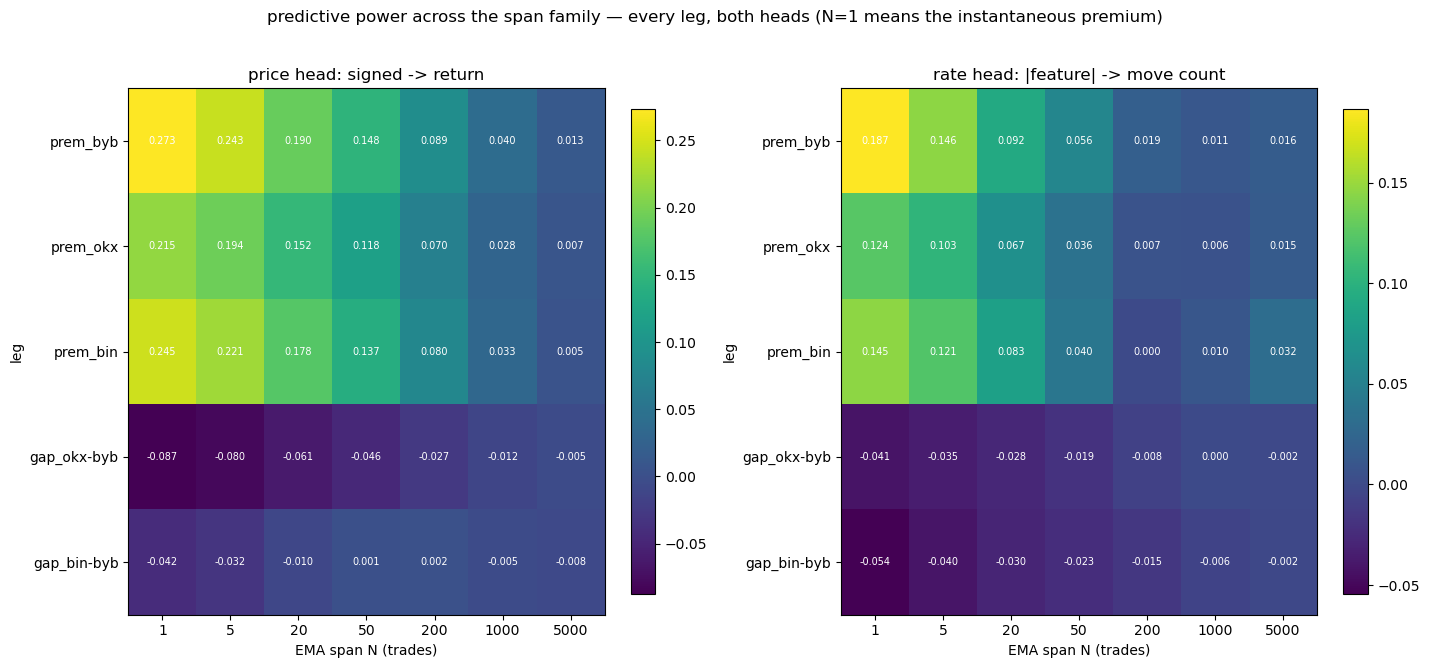

In [6]:
# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by λ_ev (the rate yardstick — the same trade-tick EMA).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (λ_ev is moves/sec over 100 ms, so this carries units of seconds; the constant horizon factor drops out of the rank correlation)

# Every leg = a per-venue premium ("prem_<ex>") or a cross-venue gap ("gap_<other>"); each built RAW.
LEGS = [("prem", v) for v in VENUES] + [("gap", o) for o in OTHERS]
def leg_value(kind, ex, N):
    return microprice_premium(ex, N) if kind == "prem" else premium_gap(ex, N)
def leg_label(kind, ex):
    return f"prem_{ex}" if kind == "prem" else f"gap_{ex}-byb"
labels = [leg_label(k, e) for k, e in LEGS]

# Sweep the span family for EVERY leg, BOTH heads, treating legs symmetrically (no assumed leader).
feat_cache = {(k, e, N): leg_value(k, e, N) for k, e in LEGS for N in NSPANS}
price_grid = {leg_label(k, e): np.full(len(NSPANS), np.nan) for k, e in LEGS}   # signed feature -> byb's signed return
rate_grid  = {leg_label(k, e): np.full(len(NSPANS), np.nan) for k, e in LEGS}   # |feature|      -> byb's move count
for k, e in LEGS:
    lab = leg_label(k, e)
    for j, N in enumerate(NSPANS):
        d = feat_cache[(k, e, N)]
        price_grid[lab][j] = spearmanr(d, target).statistic                    # predictive power for the price head
        rate_grid[lab][j]  = spearmanr(np.abs(d), rate_target).statistic       # rate head — |feature|→count DIAGNOSTIC; model is fed signed d

# heat-maps: legs (rows) × span N (cols), one per head
P = np.vstack([price_grid[l] for l in labels]); R = np.vstack([rate_grid[l] for l in labels])
fig, axes = plt.subplots(1, 2, figsize=(7.2 * 2, 0.7 * len(labels) + 3), squeeze=False)
for ax, grid, head in [(axes[0][0], P, "price head: signed -> return"), (axes[0][1], R, "rate head: |feature| -> move count")]:
    im = ax.imshow(grid, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(NSPANS))); ax.set_xticklabels(NSPANS); ax.set_xlabel("EMA span N (trades)")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.set_ylabel("leg")
    ax.set_title(head)
    for i in range(len(labels)):
        for j in range(len(NSPANS)):
            if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("predictive power across the span family — every leg, both heads (N=1 means the instantaneous premium)", y=1.02)
fig.tight_layout(); plt.show()

In [7]:
# We do NOT pick a leg (not "the best", not assumed). Every leg is kept; the model weights whichever is leading.
# Choosing the best span PER leg is fine; choosing a leg is not. Each cell is IN-SAMPLE spearmanr — used ONLY to pick a
# span, never to claim OOS power; the chosen feature is re-scored OUT-OF-SAMPLE by the §5 walk-forward gates below.
# Pick by the |IC| (the STRENGTH of the predictive power) — the SIGN is the feature's direction, which the model learns
# from the signed feature; a strongly-NEGATIVE leg (e.g. a cross-venue gap, where a +lean elsewhere precedes byb falling
# relative to it) is a strong predictor, so picking by raw IC (argmax) would wrongly select its weakest, near-zero span.
def best_span(grid): return int(np.nanargmax(np.abs(grid)))
price_member = {l: best_span(price_grid[l]) for l in labels}                    # strongest-|IC| span per leg (price head, in-sample pick)
rate_member  = {l: best_span(rate_grid[l])  for l in labels}                    # strongest-|IC| span per leg (rate head) — diagnostic readout
print("kept features (one span per leg per head; power = IN-SAMPLE |IC|, FOR SPAN SELECTION ONLY — NOT the shippable number;")
print("the OOS walk-forward marginal in §5 is the figure that counts. All legs fed to the model; the model learns the sign):")
for l in labels:
    pj, rj = price_member[l], rate_member[l]
    print(f"  {l:14}  price head N={NSPANS[pj]:>5}  power(in-sample)={price_grid[l][pj]:+.3f}   |   rate head N={NSPANS[rj]:>5}  power(in-sample)={rate_grid[l][rj]:+.3f}")

kept features (one span per leg per head; power = IN-SAMPLE |IC|, FOR SPAN SELECTION ONLY — NOT the shippable number;
the OOS walk-forward marginal in §5 is the figure that counts. All legs fed to the model; the model learns the sign):
  prem_byb        price head N=    1  power(in-sample)=+0.273   |   rate head N=    1  power(in-sample)=+0.187
  prem_okx        price head N=    1  power(in-sample)=+0.215   |   rate head N=    1  power(in-sample)=+0.124
  prem_bin        price head N=    1  power(in-sample)=+0.245   |   rate head N=    1  power(in-sample)=+0.145
  gap_okx-byb     price head N=    1  power(in-sample)=-0.087   |   rate head N=    1  power(in-sample)=-0.041
  gap_bin-byb     price head N=    1  power(in-sample)=-0.042   |   rate head N=    1  power(in-sample)=-0.054


**Reading the heat-maps.** On this block the |IC| map is **monotonic in N**: every leg peaks at the
**shortest span (N=1, the instantaneous premium)** and fades as smoothing washes the lean out — so the
in-sample span pick is N=1 for **every** leg, both heads. The **per-venue premiums** carry the signal:
price-head in-sample |IC| is **prem_byb +0.273, prem_bin +0.245, prem_okx +0.215** — byb's own premium is
the strongest, the textbook "single strongest L1 predictor" (these are in-sample, for span selection only —
the OOS walk-forward Gate B below is the figure that ships). The **cross-venue gaps come out *negative***
(gap_okx-byb **−0.087**, gap_bin-byb **−0.042**) — the *mean-reversion/echo* branch, **not** the "byb
follows the foreign lean" *lead* the §1 hunch floated: the gap opens because byb already ticked, so a +gap
precedes byb reverting. The data overrules the hunch; the picker selects by `|IC|` and the model is fed the
signed gap to learn that negative sign. We keep **every** leg.

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  prem_byb      : best alt N=    5 partial-IC|best -0.058;  OOS joint +0.252 vs solo +0.253 (Δ-0.001)  ->  one span suffices (no OOS gain)


  prem_okx      : best alt N=   20 partial-IC|best -0.089;  OOS joint +0.206 vs solo +0.200 (Δ+0.006)  ->  one span suffices (no OOS gain)


  prem_bin      : best alt N=   20 partial-IC|best -0.121;  OOS joint +0.230 vs solo +0.225 (Δ+0.004)  ->  one span suffices (no OOS gain)


  gap_okx-byb   : best alt N=   50 partial-IC|best +0.022;  OOS joint +0.081 vs solo +0.081 (Δ-0.000)  ->  one span suffices (no OOS gain)


...

  prem_byb      : best alt N=    5 partial-IC|best -0.031;  OOS joint +0.172 vs solo +0.175 (Δ-0.003)  ->  one span suffices (no OOS gain)


  prem_okx      : best alt N=   20 partial-IC|best -0.030;  OOS joint +0.117 vs solo +0.117 (Δ-0.001)  ->  one span suffices (no OOS gain)


  prem_bin      : best alt N=   50 partial-IC|best -0.044;  OOS joint +0.135 vs solo +0.138 (Δ-0.003)  ->  one span suffices (no OOS gain)


  gap_okx-byb   : best alt N= 1000 partial-IC|best +0.003;  OOS joint -0.008 vs solo -0.044 (Δ+0.036)  ->  KEEP 2nd span (adds OOS)


  gap_bin-byb   : best alt N=    5 partial-IC|best +0.015;  OOS joint -0.027 vs solo -0.059 (Δ+0.031)  ->  KEEP 2nd span (adds OOS)


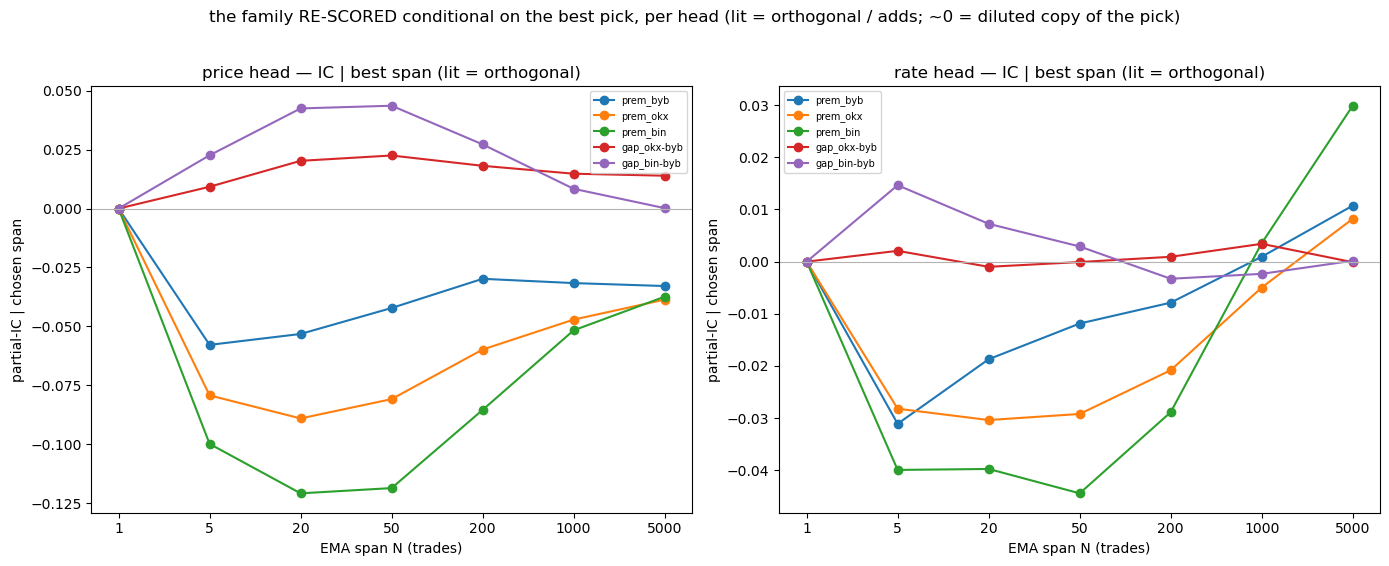

In [8]:
# === Does a SECOND time-scale ADD over the pick? — the family RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best span per head per leg by |IC|; now re-score the WHOLE span family as
# partial-IC(cell | chosen) -- each span's IC against the head's target, CONTROLLING for the span we picked (the same
# partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move). The family is a 1-D
# span sweep (one span N per leg), so this is a per-head LINE per leg, not a heat-map.
# A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES to ~0 is a diluted copy. The screen is
# in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a (leg, span) to its scored feature, tgt is the head's target, member is the in-sample pick.
HEADS = [("price head", lambda k, e, N: leg_value(k, e, N),         target,      price_member),
         ("rate head",  lambda k, e, N: np.abs(leg_value(k, e, N)), rate_target, rate_member)]
fig, axes = plt.subplots(1, len(HEADS), figsize=(7.0 * len(HEADS), 0.5 * len(labels) + 3), squeeze=False)
second = {}
for col, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    ax = axes[0][col]
    for (k, e), l in zip(LEGS, labels):
        cj = member[l]; chosen = feat(k, e, NSPANS[cj])                          # this leg's in-sample pick (the span we keep)
        cond = np.array([0.0 if j == cj else _pic(feat(k, e, N), tgt, chosen) for j, N in enumerate(NSPANS)])
        ax.plot(range(len(NSPANS)), cond, "o-", label=l)
        bj = int(np.nanargmax([abs(c) if np.isfinite(c) else -9 for c in cond])) # the most-orthogonal alternative span (in-sample screen)
        f1, f2 = chosen, feat(k, e, NSPANS[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                     # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                      # the OOS joint gain DECIDES
        second[(head, l)] = bj if keep else None
        print(f"  {l:14}: best alt N={NSPANS[bj]:>5} partial-IC|best {cond[bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
    ax.axhline(0, color="0.7", lw=0.8)
    ax.set_xticks(range(len(NSPANS))); ax.set_xticklabels(NSPANS); ax.set_xlabel("EMA span N (trades)")
    ax.set_ylabel("partial-IC | chosen span"); ax.set_title(f"{head} — IC | best span (lit = orthogonal)")
    ax.legend(fontsize=7)
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.02)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The |IC| heat-map picks the best span per head per leg; a second
span is only worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole span
family conditional on the chosen pick** — each span's IC recomputed as `partial-IC(span | chosen)`: its predictive
power against the head's target **controlling for the span we already picked** (the same partial-IC tool the
echo-netting cell uses; control = the chosen span). A span that stays **lit** is **orthogonal** — it adds new
signal — while a span that **collapses to ≈ 0** is a diluted copy of the pick. Because that screen is **in-sample**,
the keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (price → signed feature vs the σ-return target; rate → |feature| vs the count
target) and **every leg**. On this block the two heads land differently. On the **price head** the IC is
monotonic in N (the in-sample peak is at N=1) and every leg's best alternative span is a diluted, near-redundant
copy — its OOS joint gain is ≈ 0 (Δ between −0.001 and +0.006, none clearing the 0.01 floor), so **one span
suffices for every price-head leg**. On the **rate head** the three premium legs behave the same way (Δ ≈ 0,
one span suffices), but the two **cross-venue gap** legs flip to **KEEP**: `gap_okx-byb` adds a second span at
N=1000 (OOS joint −0.008 vs solo −0.044, Δ+0.036) and `gap_bin-byb` at N=5 (OOS joint −0.027 vs solo −0.059,
Δ+0.031), both well over the 0.01 floor. So the blanket "one span per head" does **not** hold — the rate head
wants a second span on the gap legs. Read that for what it is, though: both gap legs are **near-zero-IC on the
rate head** (solo IC −0.044 and −0.059, the second span only pulling the *joint* toward 0, not into clear
positive territory), so the "gain" is a marginal lift on a leg that carries little rate-head signal either way —
a noise-floor edge, not a strong orthogonal scale. We flag it (and feed both spans for those two gap legs on
the rate head) but do not over-read it; the headline edge is the price head, where one span suffices throughout.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the span pick. Held-out span selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 7-span family of near-identical neighbours, so the
selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude, so a magnitude that tracks the regime would leak
into it), two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. Each closes
what the others miss. The vol/rate level is only the regime *coordinate* here (what we bucket/correlate
against), **never** a control. Fail any one of them = a level in disguise, not a feature. **This is also the
RAW-FIRST decision point:** if the bounded premium's scale stays < ~3× it ships raw; if it fails we divide by
`σ_ev` / `λ_ev`. We *measure*, never assume.

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. The micro-price
premium is a book-pressure **alpha** (not a regime descriptor), so Gate B is its **marginal** rank-IC over
the regime-invariant controls (the momenta — **never** the raw levels), all legs together and each on
its own, want ≳ 0.01. *(A **control-type** feature — a regime descriptor like σ_ev/λ_ev — is instead
judged on its **standalone** signal.)* **Mechanical-coupling guard:** the gate scores the **σ_ev price
target** (`fwd_return/σ_ev`) by default, but the premium divides by **no** yardstick at all — it shares no
denominator with either target — so there is no spurious ratio coupling to stratify away
(`STRAT_VAR = None`). We still print the within-σ_ev stratified standalone IC below as a *confirmation* that
the unstratified IC isn't a σ_ev artefact. *Regime-stable* (companion): is Gate B still positive **within**
calm, mid, and wild vol — not a one-regime artefact?

In [9]:
# Gates on the set of per-leg features — symmetric; KEEP ALL legs. Marginal value is checked JOINTLY (do the legs
# together add over the controls?) and per-leg (does each contribute?), never by picking one.
# GATE B — predictive signal.
#   alpha (or a control's CROSS-venue leg): MARGINAL rank-IC over the base momenta — a lead test.
#   control + OWN-venue leg: STANDALONE (marginal-over-own-momenta is circular).
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). The premium is an alpha, so all legs take the marginal branch.

chosen = {l: feat_cache[(k, e, NSPANS[price_member[l]])] for (k, e), l in zip(LEGS, labels)}   # the chosen price-head feature per leg
joint = signal_ic(list(chosen.values()), own=False)
strat = signal_ic_by_regime(list(chosen.values()), own=False)
pci = wf_marginal_ci(list(chosen.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
rep = chosen[labels[0]]                                 # representative leg — for the momenta-overlap sanity print only (Gate A runs PER LEG below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER LEG
# (Gate A is a property of the output DISTRIBUTION, which differs by leg — bin is sub-ms fresh, byb/okx stale):
# scale, plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone, e.g. U-shaped, leak the monotone IC misses); each row reports the WORST coordinate.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="all legs together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{l} alone — marginal over the controls",
                   value=signal_ic([chosen[l]], own=False)) for l in labels]
# σ_ev-coupling confirmation: the premium divides by NO yardstick (STRAT_VAR=None). A within-σ_ev stratified standalone
# IC ≈ the unstratified standalone IC confirms σ_ev isn't manufacturing the rank-IC (no spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"{l} — signed premium standalone IC, unstratified", value=round(ic(chosen[l], target), 3)) for l in labels]
gate_rows += [dict(gate="B · coupling", detail=f"{l} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(chosen[l], target, sigma_at_anchor), 3)) for l in labels]
for l in labels:                                       # GATE A PER LEG (worst coordinate per check) — every leg, since the output distribution differs by leg
    a = gate_a(chosen[l])
    gate_rows += [dict(gate=f"A · regime-inv ({l})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({l})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({l})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({l})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
worst_scale = max(gate_a(chosen[l])["scale"] for l in labels)
print(f"RAW-FIRST DECISION: worst raw scale-across-vol-buckets = {worst_scale:.2f}x "
      f"({'PASS (<~3x) -> ship RAW, no normalisation' if worst_scale < 3 else 'FAIL -> try /sigma_ev or /lambda_ev'})")
pl.Config.set_tbl_rows(50); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.260  |  per-fold [0.247, 0.268, 0.213, 0.243, 0.328] (positive in 5/5)  |  block-bootstrap 90% CI [0.253, 0.266]  (block ~2000 anchors ~100.0s)


FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.003 vol 0.021  (large for an 'alpha' => it's really a control)


RAW-FIRST DECISION: worst raw scale-across-vol-buckets = 1.40x (PASS (<~3x) -> ship RAW, no normalisation)


gate,detail,value
str,str,f64
"""B · signal""","""all legs together — marginal over the invariant controls""",0.26
"""B · signal""","""prem_byb alone — marginal over the controls""",0.249
"""B · signal""","""prem_okx alone — marginal over the controls""",0.197
"""B · signal""","""prem_bin alone — marginal over the controls""",0.222
"""B · signal""","""gap_okx-byb alone — marginal over the controls""",0.077
"""B · signal""","""gap_bin-byb alone — marginal over the controls""",0.034
"""B · coupling""","""prem_byb — signed premium standalone IC, unstratified""",0.273
"""B · coupling""","""prem_okx — signed premium standalone IC, unstratified""",0.215
"""B · coupling""","""prem_bin — signed premium standalone IC, unstratified""",0.245


**Conclusion (and the raw-first decision).** The printed `RAW-FIRST DECISION` settles the normalisation
question *with a number*: the worst-case scale-across-vol-buckets is **1.40×** (the per-venue legs ≈1.1–1.23×,
the gaps 1.4×) — **well under 3×** — so the bounded premium **passes the hard regime-invariance gate RAW**,
and we ship it **without** dividing by `σ_ev` or `λ_ev`. (Had it failed, the table would have sent us to the
`/σ_ev` form — that is the whole point of raw-first: *measure, then decide*.) On the predictive gates the
price head is **exceptionally strong**: the legs jointly add **+0.260** walk-forward rank-IC over the
controls, positive in **5/5** OOS folds with a tight block-bootstrap 90% CI **[0.253, 0.266]** — by far the
strongest L1 predictor in this set. Each per-venue leg adds on its own (**prem_byb +0.249, prem_bin +0.222,
prem_okx +0.197**); the negative gaps add a smaller increment (**gap_okx-byb +0.077, gap_bin-byb +0.034** —
the joint gate scores `|IC|`-strength, so a negative-signed leg still contributes positive marginal value).
Within σ_ev strata the standalone IC barely moves (prem_byb 0.273→0.272, prem_okx 0.215→0.215, prem_bin
0.245→0.244; gaps unchanged), so the shared σ_ev isn't manufacturing it — as expected, since the premium
never divides by σ_ev (overlap with the momenta is tiny: |IC| rate 0.003, vol 0.021, confirming it really is
an alpha). Run **per leg**, Gate A clears every check: scale 1.1–1.4× (≪ 3), signed mean-track ≤ 0.02
(≪ 0.05), magnitude-track ≤ 0.031 and dispersion ≤ 0.085 (under the ~0.1 bar). The companion is positive and
*rising* across regimes (**0.241 / 0.255 / 0.288** calm / mid / wild). Verdict for the **price head**: clears
every local gate on this block, every leg — a single-block candidate; shipping is gated by §10. (The rate
head is gated separately just below.)

**Now the rate head — its own gates, against the count target.** The block above gated the *price-span*
feature against the σ_ev **price** target. The rate head is fed a **different-span** feature (the
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|feature| → count` is the §6 diagnostic, and the model
is fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores
`|feature|`** — a *linear* score on the signed feature would read ≈ 0 precisely because the count
relationship is symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts.
**Coupling guard:** the price head used `STRAT_VAR=None` because the premium divides by no yardstick; the
magnitude path has no sign, but `|feature|` is still a bounded ratio (no `1/λ_ev` factor) while
`count/λ_ev ∝ 1/λ_ev`, so they share no denominator — we add a within-λ_ev stratified line per leg to
confirm the marginal isn't a `1/λ_ev` artefact regardless. **Gate A** is re-run **per leg** on the
rate-span feature (a distribution property — it differs by leg *and* by span).

In [10]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-SPAN feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-span feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited
# from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |feature|->count is the §6 diagnostic, and the model is fed the
#    SIGNED feature and recovers |.| internally (a nonlinear head can). So Gate B scores |feature| — a LINEAR score
#    on the signed feature reads ~0 because the count relationship is symmetric; |feature| is the honest proxy.
#  * Coupling guard: |feature| is a bounded ratio (no 1/λ_ev factor) while count/λ_ev ~ 1/λ_ev — no shared
#    denominator — but we add a within-λ_ev stratified line per leg to confirm the marginal is not a 1/λ_ev artefact.
#  * Gate A is re-run PER LEG on the rate-span feature (a distribution property — it differs by leg AND by span).
prem_rate = {l: feat_cache[(k, e, NSPANS[rate_member[l]])] for (k, e), l in zip(LEGS, labels)}
mag_rate  = {l: np.abs(prem_rate[l]) for l in labels}

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |feature|->count, marginal over the controls, all legs together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)   # H5: per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is bound in §5.

rate_rows  = [dict(gate="B · signal (rate)", detail="all legs together — marginal |feature|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"{l} alone — marginal |feature|->count over the controls",
                   value=signal_ic([mag_rate[l]], own=False, tgt=rate_target)) for l in labels]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{l} — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[l], rate_target, lam_at_anchor), 3)) for l in labels]
for l in labels:
    a = gate_a(prem_rate[l])
    rate_rows += [dict(gate=f"A · regime-inv ({l})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({l})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({l})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({l})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|feature|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(50); pl.Config.set_fmt_str_lengths(75)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal 0.128  |  per-fold [0.101, 0.148, 0.119, 0.126, 0.148] (positive in 5/5)  |  block-bootstrap 90% CI [0.122, 0.135]  (block ~9479 anchors ~474.0s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""all legs together — marginal |feature|->count over the controls; want >~ 0.…",0.128
"""B · signal (rate)""","""prem_byb alone — marginal |feature|->count over the controls""",0.104
"""B · signal (rate)""","""prem_okx alone — marginal |feature|->count over the controls""",0.063
"""B · signal (rate)""","""prem_bin alone — marginal |feature|->count over the controls""",0.079
"""B · signal (rate)""","""gap_okx-byb alone — marginal |feature|->count over the controls""",-0.003
"""B · signal (rate)""","""gap_bin-byb alone — marginal |feature|->count over the controls""",-0.002
"""B · coupling (rate)""","""prem_byb — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.182
"""B · coupling (rate)""","""prem_okx — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.123
"""B · coupling (rate)""","""prem_bin — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.145


**Conclusion (rate head).** The rate-span feature clears the same battery against the **count** target.
**Gate B** — the marginal `|feature| → count` over the controls is **+0.128** jointly (positive in **5/5**
OOS folds, CI **[0.122, 0.135]**), and the **per-venue premiums** carry it on their own (**prem_byb +0.104,
prem_bin +0.079, prem_okx +0.063**, all far above the ~0.01 floor); the two cross-venue **gaps** read ≈0 on
the count target (gap_okx-byb −0.003, gap_bin-byb −0.002) — the gaps are a price-head, not a rate-head,
signal, kept anyway because the model is fed the signed feature. *Within* **λ_ev strata** the per-venue
signal stays robustly positive (**0.182 byb, 0.145 bin, 0.123 okx**), so the marginal isn't a `1/λ_ev`
artefact. **Gate A** holds per leg — scale 1.1–1.4× (≪ 3), signed mean-track ≤ 0.02, and the `|feature|` the
rate head sees only weakly tracks the regime (mag-track ≤ 0.031, dispersion ≤ 0.085, under the ~0.1 bar). The
**companion** is positive in every regime (**0.121 / 0.127 / 0.126** calm / mid / wild). So the rate head's
"keep it" is *earned* on this block for the per-venue premiums, not inherited from the price gates. (The
gaps' rate-head contribution is the loosest number — kept on the price head, marginal on the rate head.)

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor-100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.) The micro-price premium is built from the very mid it
predicts, so expect a large backward echo; whether much survives the netting is the real question.

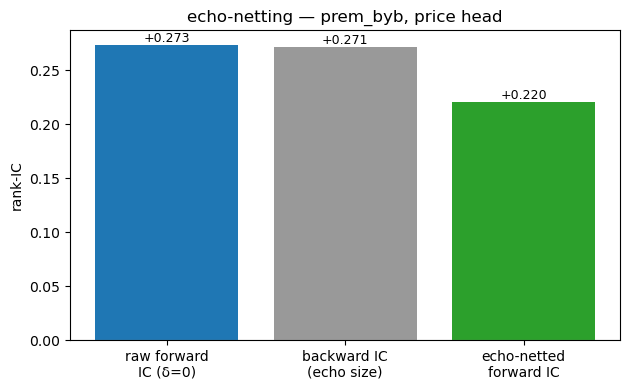

raw forward IC +0.273;  backward (echo) IC +0.271;  echo-netted forward IC +0.220  (the raw->netted shortfall is echo)


In [11]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

rep_leg = ("prem", "byb"); rep_lab = leg_label(*rep_leg)                          # byb's own premium illustrates; every leg carries its own
signed = microprice_premium(rep_leg[1], NSPANS[price_member[rep_lab]])            # the chosen price-head feature for this leg
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
bar_labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(bar_labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_lab}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor-100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100-160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
the feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high feature values — it should tilt
  one way as the feature turns positive and the other as it turns negative;
- **rate head:** how the number of upcoming moves grows as the feature's *magnitude* grows.

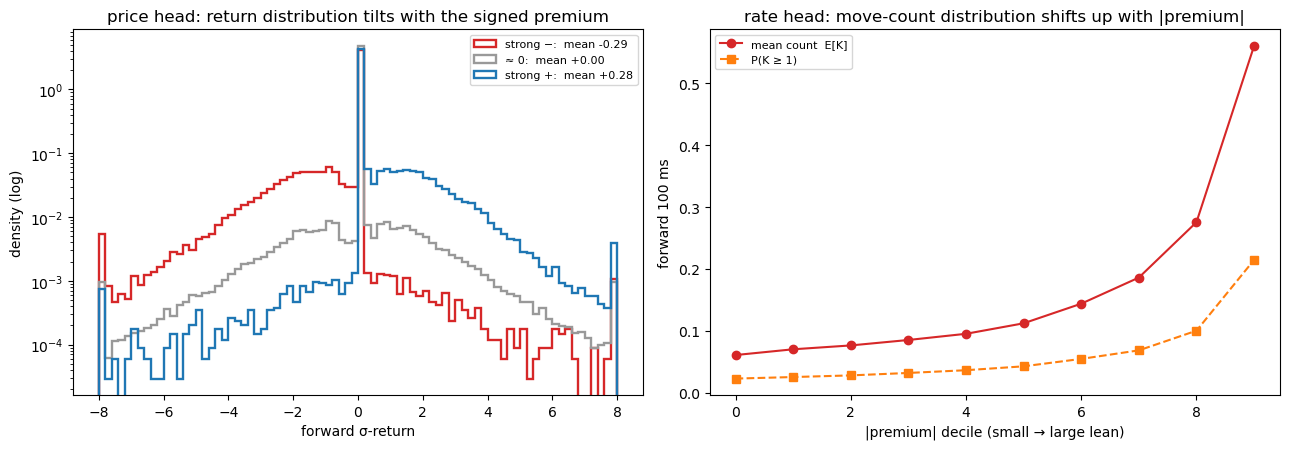

In [12]:
rep_leg = ("prem", "byb"); rep_lab = leg_label(*rep_leg)                        # byb's own premium illustrates; the model uses every leg
signed = feat_cache[(rep_leg[0], rep_leg[1], NSPANS[price_member[rep_lab]])]
absmag = np.abs(feat_cache[(rep_leg[0], rep_leg[1], NSPANS[rate_member[rep_lab]])])  # deliberately the RATE-head span (rate_member), not the price-head span
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-premium buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution tilts with the signed premium"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |premium|
# raw fwd_count is shown here only for intuition; the rate head's actual target is rate_target = fwd_count / λ_ev (count ÷ λ_ev)
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|premium| decile (small → large lean)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count distribution shifts up with |premium|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the two heads
need — not just a single summary number (shown here for byb's own premium; the model uses every leg).
**Price head (left):** the forward-return distribution shifts bodily with the *signed* premium — read the
group means in the legend (negative for the strong-negative / touch-leaning-down group, positive for the
strong-positive / leaning-up group, with the flat ≈0 group between) — so the sign genuinely carries
direction. **Rate head (right):** both the mean move-count `E[K]` and `P(K ≥ 1)` climb from the smallest to
the largest |premium| decile — a strong lean really does precede more moves. So both heads have something to
learn here, in the directions §1 predicted.

## 8. Input shaping for the network

This step is about reshaping the feature for the neural network's input — roughly centred, unit-scale,
no wild outliers. (Unlike the template, there is *no* "regime division" step to separate from: §5/§6 showed
the raw premium is already regime-invariant, so we ship it raw and only reshape here.)

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few
candidates by how close to a clean bell curve they make it (right — points on the diagonal are
perfectly normal). A symmetric, mild feature only needs a simple rescale (z-score: subtract
the mean, divide by the standard deviation); a heavily skewed or fat-tailed one needs more
(e.g. a rank-to-normal map: sort the values and reassign them onto a bell curve). The plot
makes the choice for you.

feature: std=1.58e-06  skew=+0.77  excess_kurt=384.2  (0 = normal)
  z-score            excess_kurt=   384.2   max|·|=122.3
  robust + clip ±4   excess_kurt=    -0.9   max|·|=4.0
  arcsinh(robust)    excess_kurt=    -1.3   max|·|=5.3
  rank-Gaussian      excess_kurt=    -0.0   max|·|=5.0


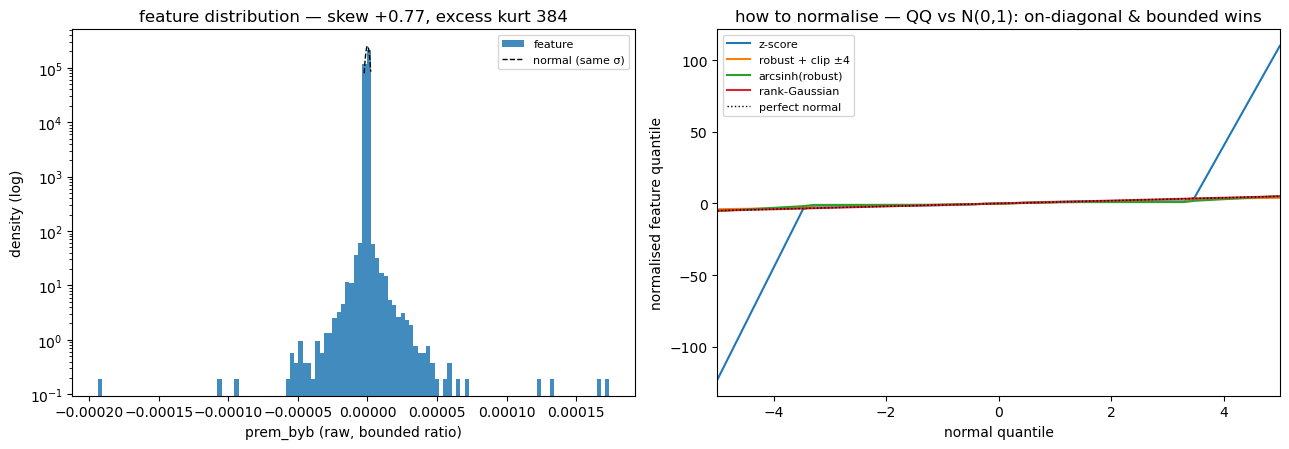

In [13]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_leg = ("prem", "byb"); rep_lab = leg_label(*rep_leg)                        # one leg shown to illustrate (same construction for every leg)
f = feat_cache[(rep_leg[0], rep_leg[1], NSPANS[price_member[rep_lab]])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-300; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-300),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.2e}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>8.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel(f"{rep_lab} (raw, bounded ratio)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution — skew {skew(f):+.2f}, excess kurt {kurtosis(f):.0f}")
axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout chooses the input transform — and it overrules the eyeball. The raw premium is
**mildly right-skewed** (skew ≈ **+0.77**, not symmetric) with **extremely heavy tails** (excess kurt ≈
**384**), so a plain z-score leaves a huge **max|·| ≈ 122σ** spike that badly violates the "no wild outliers"
bar. The lightest transform that *meets* the bar is a **robust z-score followed by a clip ±4**
(`max|·| = 4.0`, excess kurt ≈ −0.9), so clip whenever you feed a network. The heavier transforms (arcsinh
max|·| 5.3, rank-Gaussian max|·| 5.0) flatten the tails further but throw information away — the mild skew is
not large enough to force a rank-Gaussian. Note this is the **only** reshaping needed — no `/σ_ev` regime
division, because §5/§6 proved the raw premium is already regime-invariant (worst scale 1.40×).

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-leg worth it? (per-venue vs pooled)

The micro-price premium *can* be pooled — a size-weighted average premium across venues is a single
number — so we face a real choice: keep the legs **per-venue** (each venue's own premium + each
cross-venue gap), collapse to **one venue** (byb's own premium), or **pool** them into one cross-venue
premium? The answer depends on the time-scale, so sweep it and compare the three.

> **The table below is an illustrative example of the typical pattern — it is NOT computed for
> `microprice`** (whose real per-leg numbers are the heat-maps in §6). It shows the pattern a
> lead/lag feature usually follows, predicting byb's next 100 ms. The time-scale column is labelled
> in ms / seconds only for readability — those wall-clock figures are just a translation of points
> on the trade-span N clock; the actual sweep is over span N, as everywhere else.

| time-scale | pooled | best single | per-venue | what it means |
|---|---|---|---|---|
| ≤ 50 ms | 0.20 | 0.21 | **0.24** | keep per-venue — whose touch leans first genuinely differs |
| ~500 ms | 0.13 | 0.13 | **0.15** | still per-venue — the lead/lag persists a little |
| ≥ 2.5 s | 0.08 | 0.08 | 0.08 | venues agree — any one (or the pool) will do |

So: at the **shortest** scales the cross-venue lead/lag is live and per-venue clearly wins (whose
touch leans first is exactly the edge); as the span grows the venues converge and a single premium —
or the pool — says as much. In this typical pattern pooling rarely beats per-venue at the short
scales where this feature is strongest; that's why you sweep and compare the three rather than pool by
default. (Longer prediction horizons push the useful band wider, so in general sweep the horizon too.)

## 10. The verdict, and what it takes to ship

**Keep it — but on the honest numbers, not the headline.** The shippable strength is the **out-of-sample
walk-forward** marginal Gate B (§6): the legs **jointly add +0.260** rank-IC over the controls (5/5 folds,
CI [0.253, 0.266]), and **prem_byb alone adds +0.249** — the strongest single L1 predictor in this set. The
frequently-quoted **+0.273 is an *in-sample* univariate spearman used only to pick a span** (§6) — *not* the
shippable figure. Feed the *signed* feature to both heads (each head gated separately in §6), all legs (every
venue's own premium and both cross-venue gaps):
- **Price head (direction):** the signed premium — the sweep is **monotonic in N**, so the sharpest edge is
  the **freshest** read (N=1, the instantaneous premium reads the live touch imbalance); smoothing only
  washes the lean out. This is a *freshness* signal — read it raw and as fresh as your stack allows. The §6
  conditional-IC second-span test finds no orthogonal long member for **any price-head leg** (every OOS joint
  gain ≈ 0), so one span suffices on the price head. (The rate head is the exception: its two near-zero-IC
  cross-venue gap legs flag a marginal KEEP for a second span — see §6 — so "one span per head" is not blanket.)
- **Echo-netted, not echo-inflated.** The premium is built from the very mid it predicts, so the backward
  (already-happened) IC is large and ≈ the forward IC. We therefore quote the **echo-netted (partial)
  forward IC** (the echo-netting section): netting the forward return against the trailing
  `[anchor−100 ms, anchor]` move drops only a *modest* slice off the raw δ=0 IC and stays clearly positive —
  **most of the headline is genuine forward prediction**, because byb's trailing and forward 100 ms moves are
  themselves only weakly correlated. The honest verdict number is the **echo-netted** forward IC (with the
  +0.260 OOS *joint* marginal as the controls-adjusted figure), not the raw δ=0 IC and not the in-sample
  +0.273.
- **Rate head (intensity):** the *magnitude* of the premium — a large lean precedes more moves (joint Gate B
  +0.128, prem_byb +0.104 alone) — but you still feed the **signed** feature and let the rate head recover
  that, and learn how venues' leans cancel or reinforce. (Feeding pre-`|·|` per leg would block that.) The
  rate-span feature clears its **own** Gate A/B battery against the **count** target (§6).
- **The cross-venue gaps add a smaller, *negatively*-signed increment.** Measured (§6), `gap_okx-byb` and
  `gap_bin-byb` come out **negative** (price-head in-sample −0.087 / −0.042) — the **mean-reversion/echo**
  branch (the gap opens because byb already ticked, then byb reverts), **not** the "byb follows the foreign
  lean" *lead* the §1 hunch advertised. The data overrules the hunch; keep the legs and let the model learn
  the sign. Because the recording *is* production timing, a foreign-venue freshness lead is **real edge** —
  not an artifact to coarsen away (see the echo-netting section).

Feed **every leg's** signed feature in and let the model lean on whichever venue is leading at the
moment; don't collapse to a single "leader." The feature is shipped **raw** — it is a bounded ratio and
§5/§6 *measured* it regime-invariant (worst scale ≈ **1.40×** across vol buckets, far under the 3× bar),
so it is **not** divided by `σ_ev` or `λ_ev`; the move-count it predicts (rate-head target) is still divided
by the rate yardstick.

**To ship:**
- [ ] the streaming (constant-work-per-event) builder, matching this analysis version — **done,
      §4(A) is a parity match on a real block**
- [ ] both checks passing — §4(A) the production-shape streaming match (all legs) and §4(B) the
      independent plain-numpy atom + the `±halfspread/mid` bound, at the shipped N=1
- [ ] the gate results recorded (with any failures justified), incl. the **echo-netted** forward IC —
      quote the netted, not the raw δ=0, number
- [ ] the chosen heads and time-scales written down, with the yardstick spans
- [ ] the raw-first decision recorded (measured scale, raw vs /σ_ev/λ_ev)
- [ ] the data quirks handled (bad zero-price/zero-size prints; the right price source per venue)